# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [72]:
#Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [114]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn import metrics
from sklearn.impute import SimpleImputer

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [74]:
df = pd.read_csv("SuperKart.csv")
data = df.copy()


# **Data Overview**

In [75]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [77]:
# checking missing values in the data
data.isna().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

In [78]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [79]:
# Number of unique values in each column
data.nunique()

Product_Id                   8763
Product_Weight               1113
Product_Sugar_Content           4
Product_Allocated_Area        228
Product_Type                   16
Product_MRP                  6100
Store_Id                        4
Store_Establishment_Year        4
Store_Size                      3
Store_Location_City_Type        3
Store_Type                      4
Product_Store_Sales_Total    8668
dtype: int64

In [80]:
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [81]:
df['Store_Type'].unique()

array(['Supermarket Type2', 'Departmental Store', 'Supermarket Type1',
       'Food Mart'], dtype=object)

In [175]:
# Define the target variable for the regression task
target = 'Product_Store_Sales_Total'

# List of numerical features in the dataset (excluding 'Product_Id' as it is an identifier)
numeric_features = [
    'Product_Weight',         # 
    'Product_Allocated_Area', # 
    'Product_MRP',             #
]

# List of categorical features in the dataset
categorical_features = [
    'Product_Sugar_Content',  # 
    'Product_Type',    
    'Store_Id',  
    'Store_Establishment_Year',   
    'Store_Size',
    'Store_Location_City_Type',   
    'Store_Type'
]

In [176]:
# Generate summary statistics for numerical features
df[numeric_features].describe()

,Product_Weight,Product_Allocated_Area,Product_MRP
count,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539
std,2.217320,0.048204,30.694110
min,4.000000,0.004000,31.000000
25%,11.150000,0.031000,126.160000
50%,12.660000,0.056000,146.740000
75%,14.180000,0.096000,167.585000
max,22.000000,0.298000,266.000000


1. **Product Weight:**
  - Most products are between 11 and 14 units with a mean of 12 units.
2. **Product Allocated Area:**
  - The majority of products are allocated between 0.03 and 0.1 units with a mean of .07.  The max of 0.29 and min of 0.004 show that there are outliers in allocated area.
3. **Product Max Retail Price:**
  - Most products are between 126 and 168 in unit cost.  The max of 266 and min of 31 indicate there are outliers in the data.

In [225]:
# Generate summary statistics for categorical features
for cat in categorical_features:
    print(cat)
    print(df[cat].describe())
    print('-'*50)

Product_Sugar_Content
count          8763
unique            4
top       Low Sugar
freq           4885
Name: Product_Sugar_Content, dtype: object
--------------------------------------------------
Product_Type
count                      8763
unique                       16
top       Fruits and Vegetables
freq                       1249
Name: Product_Type, dtype: object
--------------------------------------------------
Store_Id
count       8763
unique         4
top       OUT004
freq        4676
Name: Store_Id, dtype: object
--------------------------------------------------
Store_Establishment_Year
count    8763.000000
mean     2002.032751
std         8.388381
min      1987.000000
25%      1998.000000
50%      2009.000000
75%      2009.000000
max      2009.000000
Name: Store_Establishment_Year, dtype: float64
--------------------------------------------------
Store_Size
count       8763
unique         3
top       Medium
freq        6025
Name: Store_Size, dtype: object
------------------

In [227]:
# Let's check the unique values for categorical variables

# list of all categorical variables
cat_col = categorical_features#df.select_dtypes(include="object").columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

Product_Sugar_Content
Low Sugar    0.557457
Regular      0.256875
No Sugar     0.173342
reg          0.012325
Name: proportion, dtype: float64
--------------------------------------------------
Product_Type
Fruits and Vegetables    0.142531
Snack Foods              0.131119
Frozen Foods             0.092548
Dairy                    0.090836
Household                0.084446
Baking Goods             0.081707
Canned                   0.077257
Health and Hygiene       0.071665
Meat                     0.070524
Soft Drinks              0.059226
Breads                   0.022823
Hard Drinks              0.021226
Others                   0.017232
Starchy Foods            0.016090
Breakfast                0.012096
Seafood                  0.008673
Name: proportion, dtype: float64
--------------------------------------------------
Store_Id
OUT004    0.533607
OUT001    0.180988
OUT003    0.153943
OUT002    0.131462
Name: proportion, dtype: float64
-----------------------------------------------

In [87]:
categorical_features

['Product_Sugar_Content',
 'Product_Type',
 'Store_Id',
 'Store_Establishment_Year',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type']

In [182]:
# Generate summary statistics for the target variable
df[target].describe()

count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64

<Axes: xlabel='Product_Sugar_Content', ylabel='Count'>

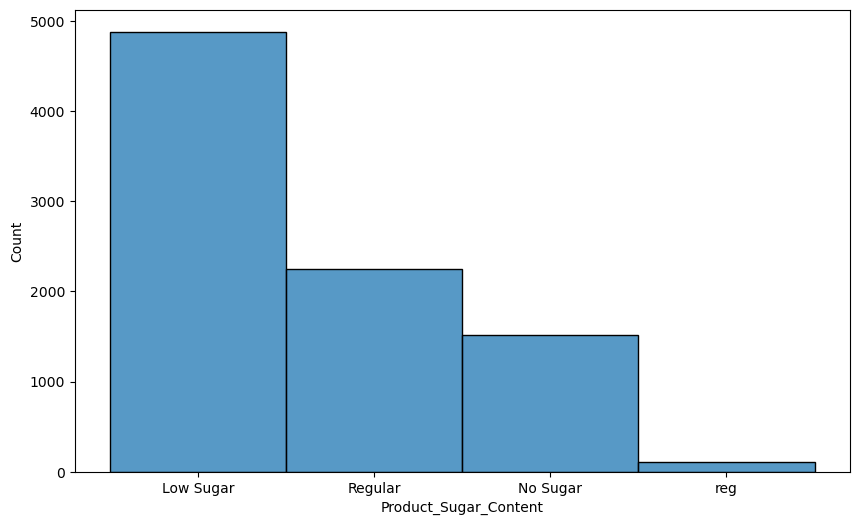

In [ ]:
# Check the distribution of the numeric variable sugar content
plt.figure(figsize=(10, 6))
sns.histplot(df[categorical_features[0]])

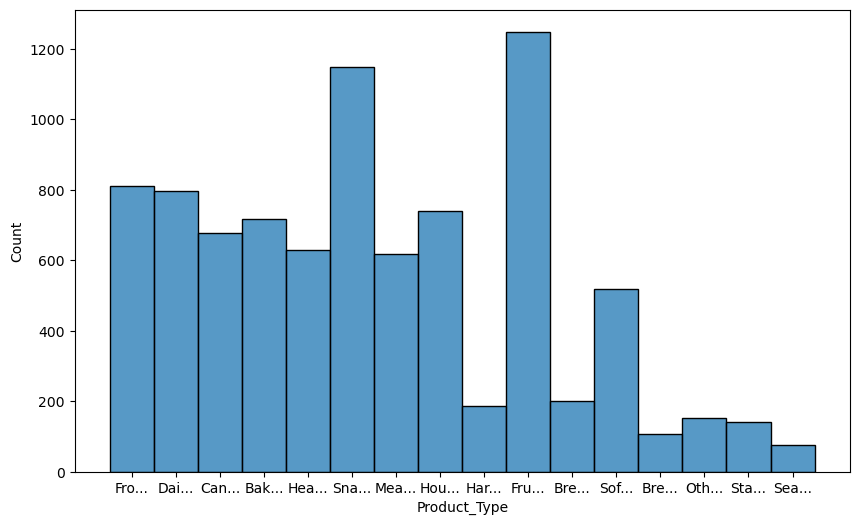

In [235]:
# Check the distribution of the numeric variable sugar content
plt.figure(figsize=(10, 6))
ax = sns.histplot(df[categorical_features[1]])

# Truncate labels to first 3 characters
labels = [label.get_text()[:3] + '...' if len(label.get_text()) > 3 else label.get_text() 
          for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.show()

<Axes: xlabel='Product_Store_Sales_Total', ylabel='Count'>

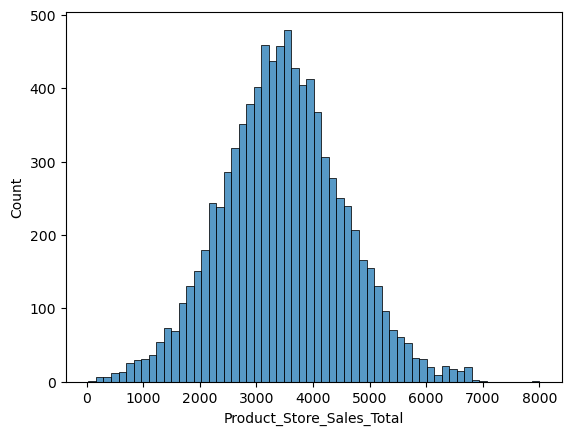

In [236]:
# Check the distribution of the target variable
sns.histplot(df[target])

* This plot shows the target variable has an even distribution around the mean of 3464.

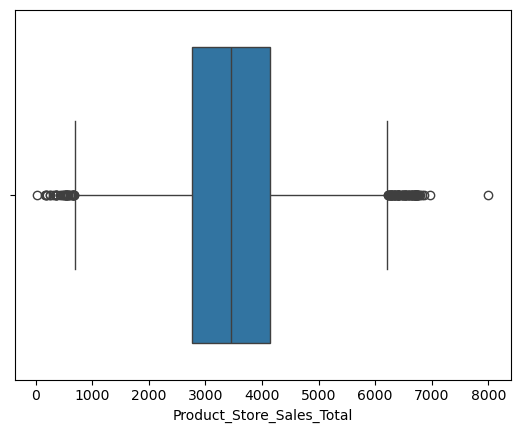

In [238]:
sns.boxplot(x=df[target])
plt.show()

* Boxplot shows an even distribution for the target variable as well, with outliers on both ends.  There is one data point at 8000 which is an extreme outlier.

## Bivariate Analysis

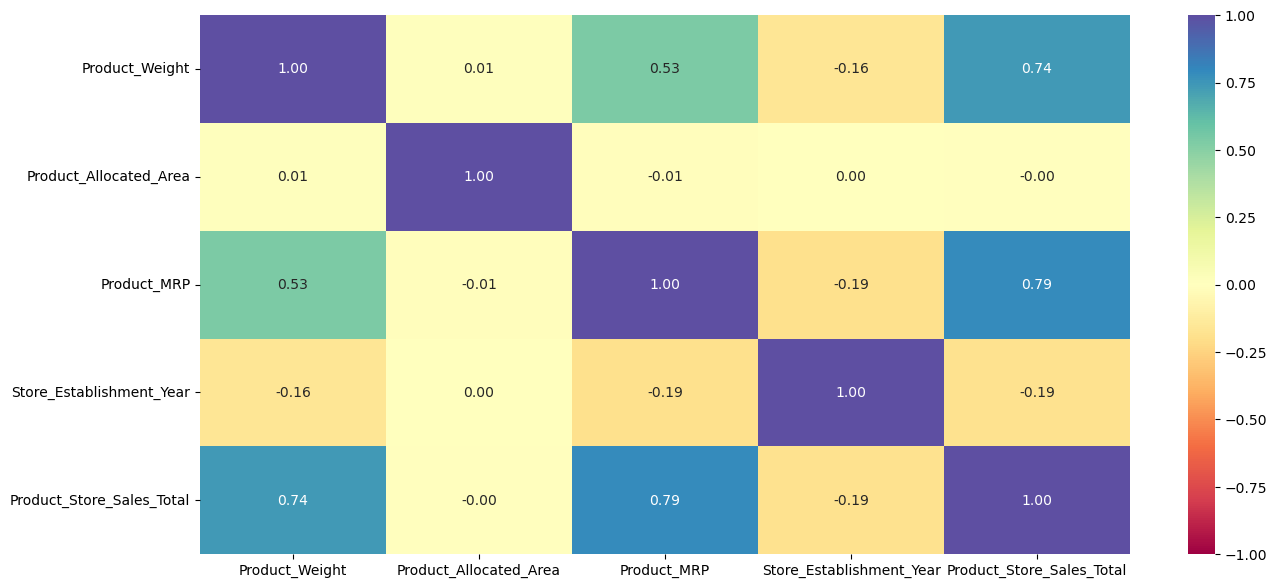

In [ ]:
# Let's check the correlation between numerical columns
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is a positive correlation between the product weight and total store sales.
* There is a positive correlation between the product max retail price and total store sales.

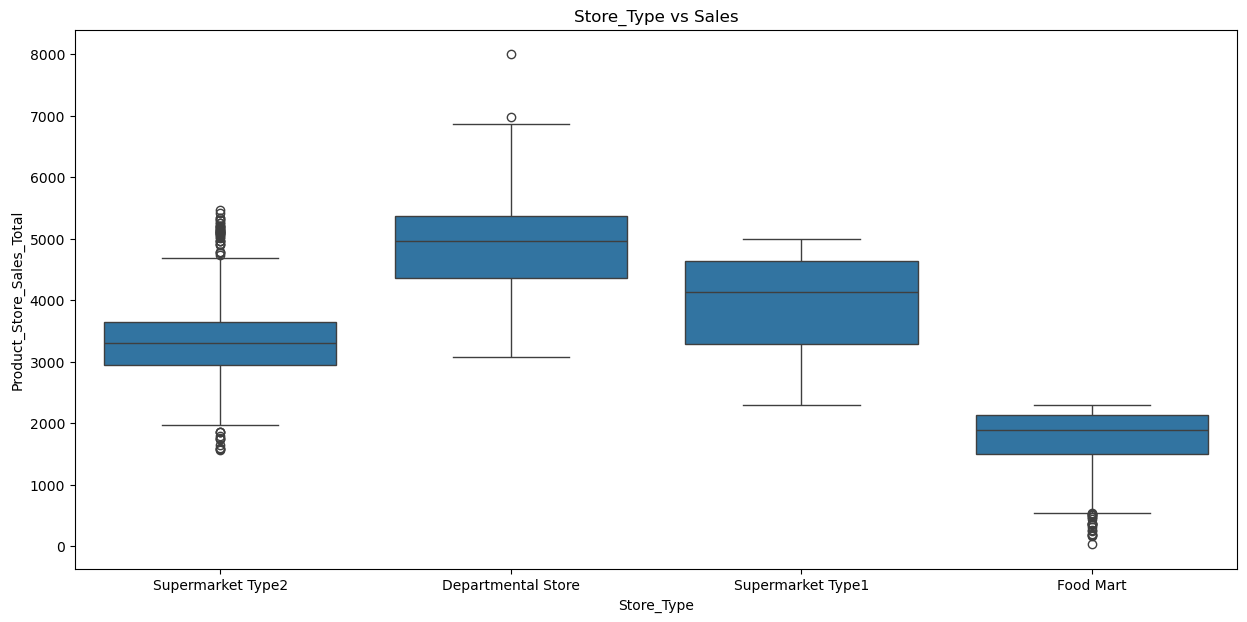

In [250]:
# Store_Type vs Product_Store_Sales_Total
plt.figure(figsize=(15, 7))
sns.boxplot(x=categorical_features[6], y="Product_Store_Sales_Total", data=df)
plt.title(categorical_features[6] + " vs Sales")
plt.show()

* Departmental stores have higher sales overall.
* Supermarket stores have outliers on the lower and higher side.
* Foot Mart stores have the least sales overall and outliers on the lower side.

# **Data Preprocessing**

### Data Preprocessing Pipeline

In [183]:
# Define predictor matrix (X) using selected numeric and categorical features
X = df[numeric_features + categorical_features]

# Define target variable
y = df[target]

In [184]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [185]:
# Create a preprocessing pipeline for numerical and categorical features

preprocessor = make_column_transformer(
    (Pipeline([('num_imputer', SimpleImputer(strategy='median')),
               ('scaler', StandardScaler())]), numeric_features),
    (Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
               ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

In [186]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

### Random Forest

In [187]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [188]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [256]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Establishment_Year',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [260]:
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance - Random Forest\n")
rf_estimator_model_train_perf

Training performance - Random Forest



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,106.938575,40.266105,0.989916,0.989901,0.015091


In [261]:
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance - Random Forest\n")
print(rf_estimator_model_test_perf)

Testing performance - Random Forest

         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  282.593974  108.343606   0.930011        0.929609  0.038681


### XGBoost

In [192]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [193]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [194]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(ha...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [195]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance - XGBoost\n")
xgb_estimator_model_train_perf

Training performance - XGBoost



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,133.463536,63.904099,0.984293,0.98427,0.022906


In [196]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance - XGBoost\n")
xgb_estimator_model_test_perf

Testing performance - XGBoost



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,308.772737,136.765948,0.916443,0.915963,0.050623


# **Model Performance Improvement - Hyperparameter Tuning**

### Random Forest - Tuned

In [251]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
rf_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_pipeline, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Establishment_Year',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=42))])

In [262]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance - Tuned RF\n")
print(rf_tuned_model_train_perf)

Training performance - Tuned RF

        RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  293.34124  155.241009   0.924122        0.924013  0.055764


In [264]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance - Tuned RF\n")
print(rf_tuned_model_test_perf)

Testing performance - Tuned RF

         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  315.369028  168.322099   0.912834        0.912334  0.059399


* Before tuning, there was a substantial gap between the train and test R-squared values (~ 0.99 vs. ~ 0.93), indicating overfitting. After tuning, this gap has increased (~ 0.924 vs. ~ 0.912), suggesting that the model is not generalizing better to unseen data.

* The R-squared on the test set has decreased from ~ 0.93 to ~ 0.91 after hyperparameter tuning. This drop indicates that the base model is better at predicting the target variable on new, unseen data.

In [ ]:
# rf_tuned_model_train_perf = rf_estimator_model_test_perf
# rf_tuned_model_test_perf = rf_estimator_model_train_perf

### XGBOOST Tuned

In [198]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor___max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor___colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor___colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor___learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor___reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_pipeline, param_grid, scoring=scorer,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

/opt/miniconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [19:36:45] WARNING: /var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_48ydvcv9e5/croot/xgboost-split_1748329884729/work/src/learner.cc:740: 
Parameters: { "_colsample_bylevel", "_colsample_bytree", "_learning_rate", "_max_depth", "_reg_lambda" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [19:36:45] WARNING: /var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_48ydvcv9e5/croot/xgboost-split_1748329884729/work/src/learner.cc:740: 
Parameters: { "_colsample_bylevel", "_colsample_bytree", "_learning_rate", "_max_depth", "_reg_lambda" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [19:36:45] WARNING: /var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_48ydvcv9e5/croot/xgboost-split_1748329884729/work/src/learner.cc:740: 
Parameters: { "_colsa

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(ha...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, ...))])

In [199]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance - Tuned XGBoost \n")
xgb_tuned_model_train_perf

Training performance - Tuned XGBoost 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,188.872248,82.694324,0.968544,0.968499,0.0304


In [200]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance - Tuned XGBoost\n")
xgb_tuned_model_test_perf

Testing performance - Tuned XGBoost



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,302.936072,132.608716,0.919572,0.91911,0.048676


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [201]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,106.938575,282.593974,133.463536,188.872248
MAE,40.266105,108.343606,63.904099,82.694324
R-squared,0.989916,0.930011,0.984293,0.968544
Adj. R-squared,0.989901,0.929609,0.984270,0.968499
MAPE,0.015091,0.038681,0.022906,0.030400


In [202]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,282.593974,106.938575,308.772737,302.936072
MAE,108.343606,40.266105,136.765948,132.608716
R-squared,0.930011,0.989916,0.916443,0.919572
Adj. R-squared,0.929609,0.989901,0.915963,0.919110
MAPE,0.038681,0.015091,0.050623,0.048676


In [203]:
(models_train_comp_df - models_test_comp_df).iloc[2]

Random Forest Estimator    0.059905
Random Forest Tuned       -0.059905
XGBoost                    0.067850
XGBoost Tuned              0.048972
Name: R-squared, dtype: float64

## Serialization

In [204]:
#TODO Choose best model, going for XGBoost-Tuned for now
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [205]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/product_sales_prediction_model_v1_0.joblib"

In [206]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at deployment_files/product_sales_prediction_model_v1_0.joblib


In [207]:
# Load the saved model pipeline from the file
saved_model = joblib.load("deployment_files/product_sales_prediction_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [208]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(ha...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, ...))])

In [209]:
saved_model.predict(X_test)

array([3403.423 , 3398.2527, 2412.714 , ..., 4117.32  , 2851.1584,
       4503.9355], shape=(1753,), dtype=float32)

# **Deployment - Backend**

## Flask Web Framework


In [ ]:
%%writefile deployment_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API
from flask.json.provider import DefaultJSONProvider

class NumpyJSONProvider(DefaultJSONProvider):
    def default(self, obj):
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# Initialize the Flask application
product_sales_predictor_api = Flask("SuperKart Product Sales Predictor")
product_sales_predictor_api.json = NumpyJSONProvider(product_sales_predictor_api)

# Load the trained machine learning model
model = joblib.load("product_sales_prediction_model_v1_0.joblib")

# Define a route for the home page (GET request)
@product_sales_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the SuperKart Sales Prediction API!"

# Define a route for the home page (GET request)
@product_sales_predictor_api.get('/v1/test')
def test():
    """
    This function handles GET requests to the test URL ('/v1/test') of the API.
    It returns a simple welcome message.
    """
    return "Testing testing 1 2 3"

# Define an endpoint for single property prediction (POST request)
@product_sales_predictor_api.post('/v1/sales')
def predict_product_sales():
    # print("predict_product_sales called...")
    """
    This function handles POST requests to the '/v1/sales' endpoint.
    It expects a JSON payload containing property details and returns
    the predicted sales projection as a JSON response.
    """
    # Get the JSON data from the request body
    property_data = request.get_json()
    print("got property data from request")
    # Extract relevant features from the JSON data
    sample = {
        'Product_Weight': property_data['Product_Weight'],
        'Product_Allocated_Area': property_data['Product_Allocated_Area'],
        'Product_MRP': property_data['Product_MRP'],
        # 'Product_Store_Sales_Total': property_data['Product_Store_Sales_Total'],
        'Product_Sugar_Content': property_data['Product_Sugar_Content'],
        'Product_Type': property_data['Product_Type'],
        'Store_Id': property_data['Store_Id'],
        'Store_Establishment_Year': property_data['Store_Establishment_Year'],
        'Store_Size': property_data['Store_Size'],
        'Store_Location_City_Type': property_data['Store_Location_City_Type'],
        'Store_Type': property_data['Store_Type'],
    }

    # Convert the extracted data into a Pandas DataFrame
    input_data = pd.DataFrame([sample])

    # Predict sales
    predicted_sales = model.predict(input_data)[0]

    # Convert predicted_price to Python float
    # predicted_price = round(float(predicted_price), 2)
    # The conversion above is needed as we convert the model prediction (log price) to actual price using np.exp, which returns predictions as NumPy float32 values.
    # When we send this value directly within a JSON response, Flask's jsonify function encounters a datatype error

    # Return the actual sales
    return jsonify({'Predicted Sales (in dollars)': predicted_sales})
                     

# Define an endpoint for batch prediction (POST request)
@product_sales_predictor_api.post('/v1/salesbatch')
def predict_product_sales_batch():
    """
    This function handles POST requests to the '/v1/salesbatch' endpoint.
    It expects a CSV file containing property details for multiple properties
    and returns the predicted sales prediction as a dictionary in the JSON response.
    """
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the CSV file into a Pandas DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for all properties in the DataFrame 
    predicted_sales = model.predict(input_data).tolist()

    # Calculate actual prices
    # predicted_prices = [round(float(np.exp(log_price)), 2) for log_price in predicted_log_prices]

    # Create a dictionary of predictions with property IDs as keys
    product_ids = input_data['Product_Id'].tolist()  # Assuming 'Product_Id' is the property ID column
    output_dict = dict(zip(product_ids, predicted_sales))  # Use actual prices

    # Return the predictions dictionary as a JSON response
    return output_dict

# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    product_sales_predictor_api.run(debug=True)

Overwriting deployment_files/app.py


## Dependencies File

In [135]:
%%writefile deployment_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

Writing deployment_files/requirements.txt


## Dockerfile

In [136]:
%%writefile deployment_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:product_sales_predictor_api"]

Writing deployment_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
#Space created manually through HF web using blank Docker template

## Uploading Files to Hugging Face Space (Docker Space)

In [219]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(override=True)
key = os.getenv("HF_KEY")
repo = os.getenv("HF_REPO")

repo_id = repo  # Your Hugging Face space id

# Login to your Hugging Face account using your access token
login(token=key)

# Initialize the API
api = HfApi()

print("Uploading to space ", repo)

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="./deployment_files",  # Local folder path
    repo_id=repo,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Uploading to space  apgt60/superkart


Processing Files (1 / 1): 100%|██████████|  208kB /  208kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


CommitInfo(commit_url='https://huggingface.co/spaces/apgt60/superkart/commit/ceed4be7f717bc57aa38f2972d500cab064a8468', commit_message='Upload folder using huggingface_hub', commit_description='', oid='ceed4be7f717bc57aa38f2972d500cab064a8468', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/apgt60/superkart', endpoint='https://huggingface.co', repo_type='space', repo_id='apgt60/superkart'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [138]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [139]:
categorical_features

['Product_Sugar_Content',
 'Product_Type',
 'Store_Id',
 'Store_Establishment_Year',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type']

In [145]:
for cat in numeric_features:
    print(cat)
    print(df[cat].head())
    print("-"*50)

Product_Weight
0    12.66
1    16.54
2    14.28
3    12.10
4     9.57
Name: Product_Weight, dtype: float64
--------------------------------------------------
Product_Allocated_Area
0    0.027
1    0.144
2    0.031
3    0.112
4    0.010
Name: Product_Allocated_Area, dtype: float64
--------------------------------------------------
Product_MRP
0    117.08
1    171.43
2    162.08
3    186.31
4    123.67
Name: Product_MRP, dtype: float64
--------------------------------------------------
Product_Store_Sales_Total
0    2842.40
1    4830.02
2    4130.16
3    4132.18
4    2279.36
Name: Product_Store_Sales_Total, dtype: float64
--------------------------------------------------


In [159]:
#junk
status_code=200
errormessage = "Error making prediction.  Got response code " + str(status_code)
errormessage

'Error making prediction.  Got response code 200'

In [170]:
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [220]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

# Set the title of the Streamlit app
st.title("Superkart Product Sales Prediction")

# Section for online prediction
st.subheader("Online Prediction")

# Collect user input for property features
sugar_content = st.selectbox("Product_Sugar_Content", ['Low Sugar','Regular','No Sugar','reg'])
product_type = st.selectbox("Product Type", ['Frozen Foods','Dairy','Canned','Baking Goods','Health and Hygiene',
 'Snack Foods','Meat','Household','Hard Drinks','Fruits and Vegetables',
 'Breads','Soft Drinks','Breakfast','Others','Starchy Foods','Seafood'])
store_id = st.selectbox("Store ID", ['OUT004','OUT003','OUT001','OUT002'])
store_est_year = st.selectbox("Store Establishment Year", ['2009','1999','1987','1998'])
store_size = st.selectbox("Store Size", ['Medium','High','Small'])
store_city_type = st.selectbox("Store Location City Type", ['Tier 2','Tier 1','Tier 3'])
store_type = st.selectbox("Store Type", ['Supermarket Type2','Departmental Store','Supermarket Type1','Food Mart'])
product_weight = st.number_input("Product Weight")
product_allocated_area = st.number_input("Product Allocated Area")
product_mrp = st.number_input("Product Max Retail Price")


# Convert user input into a DataFrame
input_data = pd.DataFrame([{
    'Product_Sugar_Content': sugar_content,
    'Product_Type': product_type,
    'Store_Id': store_id,
    'Store_Establishment_Year': store_est_year,
    'Store_Size': store_size,
    'Store_Location_City_Type': store_city_type,
    'Store_Type': store_type,
    'Product_Weight': product_weight,
    'Product_Allocated_Area': product_allocated_area,
    'Product_MRP': product_mrp
}])

# Make prediction when the "Predict" button is clicked
if st.button("Predict"):
    response = requests.post("https://apgt60-superkart.hf.space/v1/sales", json=input_data.to_dict(orient='records')[0])  # Send data to Flask API
    if response.status_code == 200:
        prediction = response.json()['Predicted Sales (in dollars)']
        st.success(f"Predicted Product Sales (in dollars): {prediction}")
    else:
        errormessage = "Error making prediction.  Got response code " + str(response.status_code)
        st.error(errormessage)

# Section for batch prediction
st.subheader("Batch Prediction")

# Allow users to upload a CSV file for batch prediction
uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])

# Make batch prediction when the "Predict Batch" button is clicked
if uploaded_file is not None:
    if st.button("Predict Batch"):
        response = requests.post("https://huggingface.co/spaces/apgt60/superkart/v1/salesbatch", files={"file": uploaded_file})  # Send file to Flask API
        if response.status_code == 200:
            predictions = response.json()
            st.success("Batch predictions completed!")
            st.write(predictions)  # Display the predictions
        else:
            st.error("Error making batch prediction.")

Overwriting frontend_files/app.py


## Dependencies File

In [147]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Writing frontend_files/requirements.txt


## DockerFile

In [148]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [221]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi
login(token=key)
repo_id = 'apgt60/superkartFE' # Your Hugging Face space id

# Initialize the API
api = HfApi()


# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="./frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/apgt60/SuperkartFE/commit/3ba8e04fe184c83098fe0b5c36c3b009febad22e', commit_message='Upload folder using huggingface_hub', commit_description='', oid='3ba8e04fe184c83098fe0b5c36c3b009febad22e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/apgt60/SuperkartFE', endpoint='https://huggingface.co', repo_type='space', repo_id='apgt60/SuperkartFE'), pr_revision=None, pr_num=None)

# **Actionable Insights and Business Recommendations**

-

-